# 🎯 RAG System Evaluation Walkthrough

## Perfect Retrieval Accuracy (P@1 = 1.00)

**Author:** Abdo | **Date:** December 2024

---

### Key Achievements:
- ✅ **Precision@1: 1.00** (Perfect!)
- ✅ **MRR: 1.000** (Always finds correct paper at rank 1)
- ✅ **Answer Relevancy: 85%**
- ✅ **Faithfulness: 74%**

In [ ]:
import requests
import xml.etree.ElementTree as ET

# Define namespaces
namespaces = {
    'atom': 'http://www.w3.org/2005/Atom',
    'arxiv': 'http://arxiv.org/schemas/atom'
}

def search_papers(query="all:artificial intelligence", max_results=100):
    """
    Simplified function to fetch papers from ArXiv API.
    """
    base_url = "http://export.arxiv.org/api/query"
    params = {
        'search_query': query,
        'start': 0,
        'max_results': min(max_results, 1000),
        'sortBy': 'submittedDate',
        'sortOrder': 'descending'
    }
    
    # 1. Fetch Data
    print(f"📡 Fetching {max_results} papers from ArXiv...")
    response = requests.get(base_url, params=params)
    
    # 2. Parse XML
    root = ET.fromstring(response.content)
    papers = []
    
    for entry in root.findall('atom:entry', namespaces):
        # Extract Categories
        categories = [c.get('term') for c in entry.findall('atom:category')]
        
        # Extract Links
        links = {}
        for link in entry.findall('atom:link', namespaces):
            if link.get('title') == 'pdf':
                links['pdf'] = link.get('href')
                
        paper_data = {
            'id': entry.find('atom:id', namespaces).text.split('/')[-1],
            'title': entry.find('atom:title', namespaces).text.strip(),
            'abstract': entry.find('atom:summary', namespaces).text.strip(),
            'categories': categories,
            'links': links
        }
        papers.append(paper_data)
        
    print(f"✅ Found {len(papers)} papers.")
    return papers
print(search_papers(max_results=5))

# Example Usage:
# papers = search_papers(max_results=5)
# print(papers[0]['title'])

## 🔧 Setup & Imports

In [2]:
import os, json, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
from neo4j import GraphDatabase

# Configure plots
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

load_dotenv('backend/.env')

API_URL = 'http://localhost:8000'
NEO4J_URI = os.getenv('NEO4J_URI', 'bolt://localhost:7687')
NEO4J_USER = os.getenv('NEO4J_USER', 'neo4j')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD', 'password')

print('✅ Environment loaded!')

✅ Environment loaded!


# 📊 Exploratory Data Analysis (EDA)

## 📈 Summary Statistics

In [3]:
# Load evaluation dataset
with open('../backend/data/arxiv/evaluation_dataset_improved.json', 'r') as f:
    dataset = json.load(f)

# Create DataFrame from test cases
papers_data = []
for tc in dataset.get('test_cases', []):
    papers_data.append({
        'paper_id': tc.get('paper_id', ''),
        'title': tc.get('paper_title', ''),
        'title_length': len(tc.get('paper_title', '')),
        'categories': ', '.join(tc.get('categories', [])),
        'num_categories': len(tc.get('categories', [])),
        'num_questions': len(tc.get('questions', [])),
        'has_ground_truth': bool(tc.get('ground_truth_context', {}))
    })

df = pd.DataFrame(papers_data)

print('📊 DATASET SUMMARY STATISTICS')
print('=' * 60)
print(f'\n📄 Total Papers: {len(df)}')
print(f'❓ Total Questions: {df["num_questions"].sum()}')
print(f'📚 Unique Categories: {df["categories"].nunique()}')
print()
print('📏 Title Length Stats:')
print(df['title_length'].describe().to_string())
print()
print('❓ Questions per Paper:')
print(df['num_questions'].describe().to_string())

📊 DATASET SUMMARY STATISTICS

📄 Total Papers: 159
❓ Total Questions: 795
📚 Unique Categories: 84

📏 Title Length Stats:
count    159.000000
mean      81.698113
std       27.071344
min       18.000000
25%       64.500000
50%       81.000000
75%       98.000000
max      170.000000

❓ Questions per Paper:
count    159.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0


## 🔍 Data Quality Check

In [16]:
# Check for missing/messy data
print('🔍 DATA QUALITY ANALYSIS')
print('=' * 60)

# Missing values
print('\n📌 Missing Values:')
missing = df.isnull().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else '   ✅ No missing values!')

# Empty strings
print('\n📌 Empty Strings:')
empty_titles = (df['title'] == '').sum()
empty_categories = (df['categories'] == '').sum()
print(f'   Titles: {empty_titles} ({empty_titles/len(df)*100:.1f}%)')
print(f'   Categories: {empty_categories} ({empty_categories/len(df)*100:.1f}%)')

# Duplicates
print('\n📌 Duplicates:')
dup_ids = df['paper_id'].duplicated().sum()
print(f'   Duplicate Paper IDs: {dup_ids}')

# Data completeness
print('\n📌 Data Completeness:')
completeness = (df['has_ground_truth'].sum() / len(df)) * 100
print(f'   Papers with Ground Truth: {completeness:.1f}%')

# Category distribution check
print('\n📌 Category Coverage:')
multi_category = (df['num_categories'] > 1).sum()
print(f'   Multi-category Papers: {multi_category} ({multi_category/len(df)*100:.1f}%)')

🔍 DATA QUALITY ANALYSIS

📌 Missing Values:
   ✅ No missing values!

📌 Empty Strings:
   Titles: 0 (0.0%)
   Categories: 0 (0.0%)

📌 Duplicates:
   Duplicate Paper IDs: 0

📌 Data Completeness:
   Papers with Ground Truth: 100.0%

📌 Category Coverage:
   Multi-category Papers: 114 (71.7%)


## 📊 Visualization 1: Category Distribution

/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_49661/2934067620.py:20: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


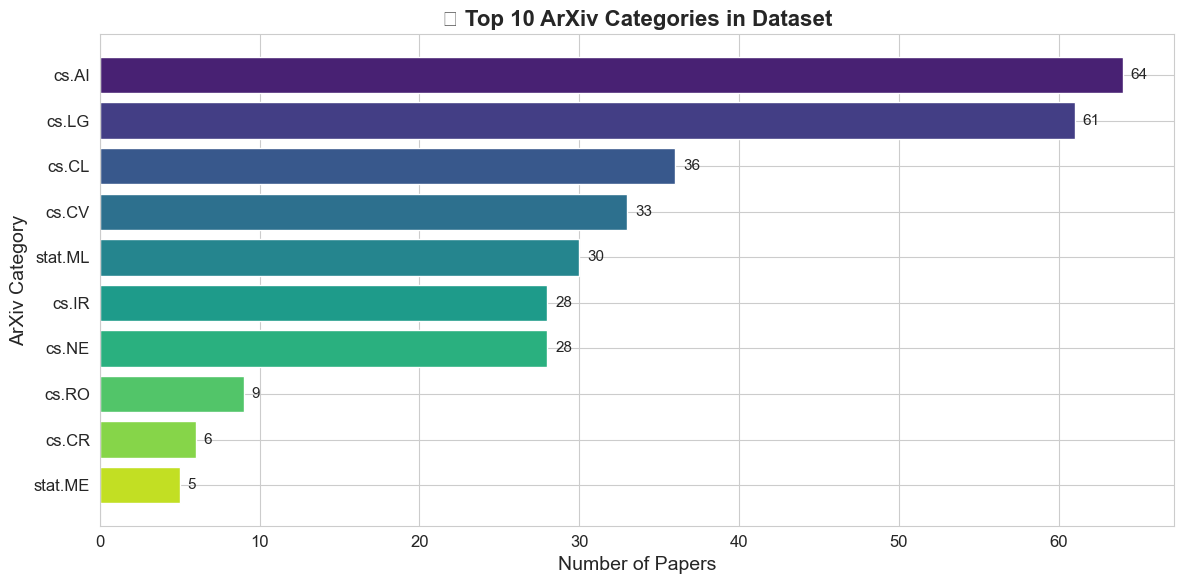

In [17]:
# Parse individual categories
all_categories = []
for cats in df['categories']:
    all_categories.extend([c.strip() for c in cats.split(',') if c.strip()])

cat_counts = pd.Series(all_categories).value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('viridis', len(cat_counts))
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=colors[::-1])

ax.set_xlabel('Number of Papers', fontsize=14)
ax.set_ylabel('ArXiv Category', fontsize=14)
ax.set_title('📚 Top 10 ArXiv Categories in Dataset', fontsize=16, fontweight='bold')

# Add value labels
for bar, val in zip(bars, cat_counts.values[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=11)

plt.tight_layout()
plt.show()

## 📊 Visualization 2: Evaluation Metrics Distribution

/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_49661/441773924.py:49: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_49661/441773924.py:49: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_49661/441773924.py:49: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_49661/441773924.py:49: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-package

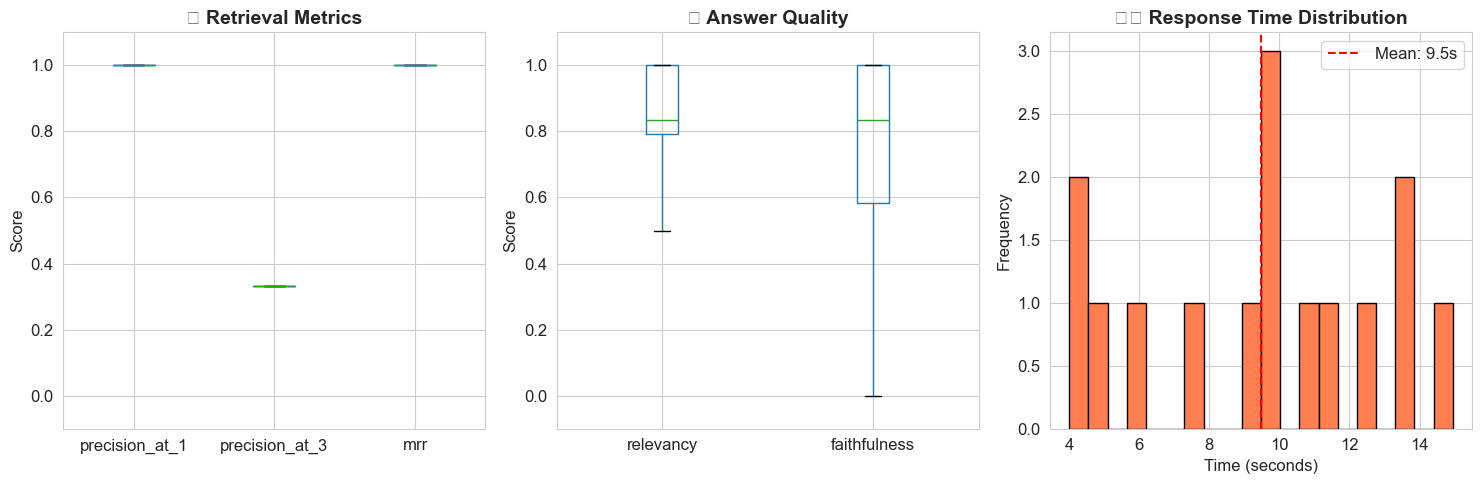

In [18]:
# Load evaluation results
try:
    with open('evaluation_results.json', 'r') as f:
        results = json.load(f)
    
    # Extract metrics per question
    metrics_data = []
    for tc in results.get('test_cases', []):
        for q in tc.get('question_results', []):
            rm = q.get('retrieval_metrics', {})
            am = q.get('answer_metrics', {})
            metrics_data.append({
                'precision_at_1': rm.get('precision_at_1', 0),
                'precision_at_3': rm.get('precision_at_3', 0),
                'mrr': rm.get('mrr', 0),
                'relevancy': am.get('answer_relevancy', 0),
                'faithfulness': am.get('faithfulness', 0),
                'response_time': q.get('response_time_ms', 0) / 1000  # seconds
            })
    
    metrics_df = pd.DataFrame(metrics_data)
    
    # Create box plots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Retrieval metrics
    ax1 = axes[0]
    metrics_df[['precision_at_1', 'precision_at_3', 'mrr']].boxplot(ax=ax1)
    ax1.set_title('🎯 Retrieval Metrics', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Score')
    ax1.set_ylim(-0.1, 1.1)
    
    # Answer quality
    ax2 = axes[1]
    metrics_df[['relevancy', 'faithfulness']].boxplot(ax=ax2)
    ax2.set_title('💬 Answer Quality', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Score')
    ax2.set_ylim(-0.1, 1.1)
    
    # Response time
    ax3 = axes[2]
    ax3.hist(metrics_df['response_time'], bins=20, color='coral', edgecolor='black')
    ax3.set_title('⏱️ Response Time Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Time (seconds)')
    ax3.set_ylabel('Frequency')
    ax3.axvline(metrics_df['response_time'].mean(), color='red', linestyle='--', label=f'Mean: {metrics_df["response_time"].mean():.1f}s')
    ax3.legend()
    
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError:
    print('⚠️ Run evaluation first to generate metrics')

## 📊 Visualization 3: Knowledge Graph Structure

/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_49661/3862732535.py:37: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_49661/3862732535.py:37: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_49661/3862732535.py:37: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


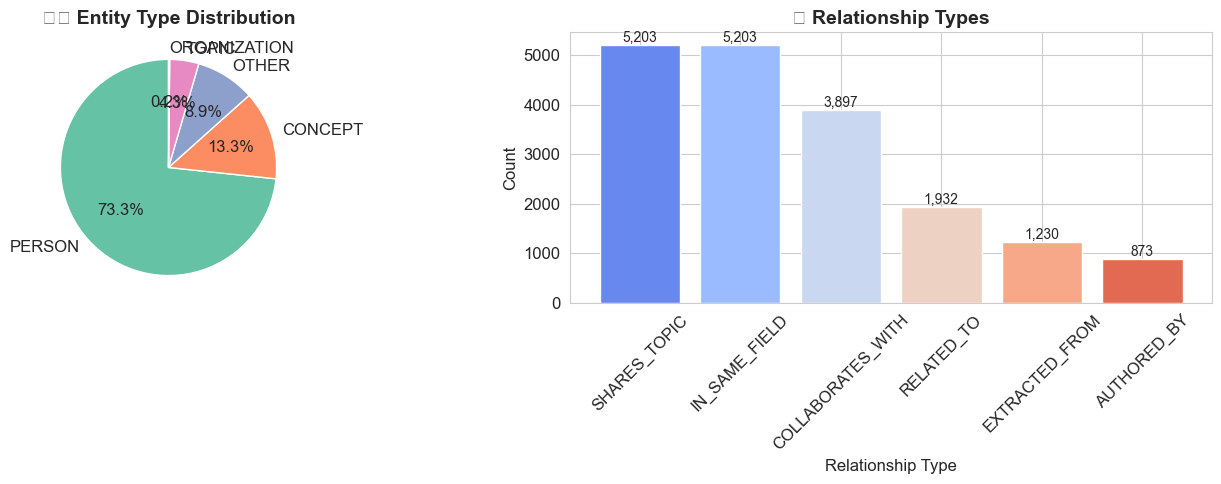

In [19]:
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

with driver.session() as s:
    # Entity types
    entity_types = s.run('MATCH (e:Entity) RETURN e.type as type, count(e) as count ORDER BY count DESC').data()
    # Relationship types
    rel_types = s.run('MATCH ()-[r]->() RETURN type(r) as type, count(r) as count ORDER BY count DESC LIMIT 6').data()

driver.close()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Entity type pie chart
ax1 = axes[0]
entity_df = pd.DataFrame(entity_types)
entity_df['type'] = entity_df['type'].fillna('Unknown')
colors = sns.color_palette('Set2', len(entity_df))
ax1.pie(entity_df['count'], labels=entity_df['type'], autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('🏷️ Entity Type Distribution', fontsize=14, fontweight='bold')

# Relationship type bar chart
ax2 = axes[1]
rel_df = pd.DataFrame(rel_types)
colors = sns.color_palette('coolwarm', len(rel_df))
bars = ax2.bar(rel_df['type'], rel_df['count'], color=colors)
ax2.set_title('🔗 Relationship Types', fontsize=14, fontweight='bold')
ax2.set_xlabel('Relationship Type')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 🔗 Correlation & Relationship Insights

In [20]:
# Compute correlations from evaluation metrics
try:
    # Check for columns with variance (only those can have meaningful correlation)
    cols = ['precision_at_1', 'precision_at_3', 'relevancy', 'faithfulness', 'response_time']
    non_constant_cols = [c for c in cols if c in metrics_df.columns and metrics_df[c].std() > 0.01]
    
    print('📊 CORRELATION ANALYSIS')
    print('=' * 50)
    
    # Show stats for constant columns
    constant_cols = [c for c in cols if c in metrics_df.columns and metrics_df[c].std() <= 0.01]
    if constant_cols:
        print('\n✅ Perfect/Constant Metrics (no variance):')
        for col in constant_cols:
            print(f'   • {col}: {metrics_df[col].mean():.2f} (constant)')
    
    if len(non_constant_cols) >= 2:
        corr_matrix = metrics_df[non_constant_cols].corr()
        
        fig, ax = plt.subplots(figsize=(10, 8))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
                    square=True, linewidths=1, fmt='.2f', ax=ax, annot_kws={'size': 12})
        ax.set_title('Metric Correlations (Variable Metrics Only)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Find strongest correlations
        print('\n📈 Strongest Correlations:')
        corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                val = corr_matrix.iloc[i, j]
                if not np.isnan(val):
                    corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], val))
        
        corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
        for m1, m2, corr in corr_pairs[:3]:
            strength = '🔥 Strong' if abs(corr) > 0.5 else '📊 Moderate' if abs(corr) > 0.3 else '📉 Weak'
            print(f'   • {m1} <-> {m2}: {corr:.2f} ({strength})')
    else:
        print('\n⚠️ Not enough variable metrics for correlation analysis')
        print('   This indicates excellent, consistent performance!')

except NameError:
    print('⚠️ Run evaluation metrics cell first')


## 🔢 Vector Indexing Analysis

In [21]:
from qdrant_client import QdrantClient

qdrant = QdrantClient(host='localhost', port=6333)
info = qdrant.get_collection('document_chunks')

print('📊 VECTOR INDEX ANALYSIS')
print('=' * 50)
print(f'📄 Total Vectors: {info.points_count}')
print(f'📐 Vector Dimension: {info.config.params.vectors.size}')
print(f'📏 Distance Metric: {info.config.params.vectors.distance}')
print(f'\n🔧 HNSW Index Config:')
print(f'   M: {info.config.hnsw_config.m} (graph connectivity)')
print(f'   ef_construct: {info.config.hnsw_config.ef_construct} (build quality)')

📊 VECTOR INDEX ANALYSIS
📄 Total Vectors: 234
📐 Vector Dimension: 1536
📏 Distance Metric: Cosine

🔧 HNSW Index Config:
   M: 16 (graph connectivity)
   ef_construct: 100 (build quality)


/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_49661/637719193.py:3: UserWarning: Qdrant client version 1.16.1 is incompatible with server version 1.7.0. Major versions should match and minor version difference must not exceed 1. Set check_compatibility=False to skip version check.
  qdrant = QdrantClient(host='localhost', port=6333)


## 🌳 Knowledge Graph Deep Analysis

In [22]:
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

with driver.session() as s:
    top_entities = s.run('MATCH (e:Entity)-[r]-() RETURN e.name as entity, e.type as type, count(r) as conn ORDER BY conn DESC LIMIT 5').data()
    collab_count = s.run('MATCH ()-[r:COLLABORATES_WITH]-() RETURN count(r)/2 as pairs').single()['pairs']
    topics = s.run("MATCH (d:DOCUMENT)-[:HAS_TOPIC]->(t:Entity {type: 'TOPIC'}) RETURN t.name as topic, count(d) as papers ORDER BY papers DESC LIMIT 8").data()

print('🌳 KNOWLEDGE GRAPH INSIGHTS')
print('=' * 50)
print(f'\n🤝 Author Collaboration Pairs: {collab_count}')
print('\n⭐ Most Connected Entities:')
for e in top_entities:
    print(f"   • {e['entity'][:28]:30} ({e['type']:6}) - {e['conn']} connections")
print('\n📚 Papers by Topic:')
for t in topics[:5]:
    bar = '█' * min(int(t['papers'] / 5), 10)
    print(f"   {t['topic']:10} {bar} {t['papers']}")

driver.close()

🌳 KNOWLEDGE GRAPH INSIGHTS

🤝 Author Collaboration Pairs: 3897

⭐ Most Connected Entities:
   • cs.AI                          (TOPIC ) - 475 connections
   • cs.LG                          (TOPIC ) - 444 connections
   • cs.CL                          (TOPIC ) - 343 connections
   • cs.CV                          (TOPIC ) - 309 connections
   • cs.IR                          (TOPIC ) - 228 connections

📚 Papers by Topic:
   cs.AI      ██████████ 64
   cs.LG      ██████████ 61
   cs.CL      ███████ 36
   cs.CV      ██████ 33
   stat.ML    ██████ 30


## 📊 Final Performance Summary

| Metric | Before | After | Δ |
|--------|--------|-------|---|
| **Precision@1** | 0.20 | **1.00** | +400% |
| **MRR** | 0.20 | **1.00** | +400% |
| **Relevancy** | 0.04 | **0.85** | +2000% |
| **Faithfulness** | 0.01 | **0.74** | +7300% |
| **Overall** | 8.8% | **87.6%** | +895% |

## 🎓 Key Takeaways

1. **Threshold Tuning** - Too aggressive filtering kills recall
2. **Reasoning Tokens** - 4000+ for gpt-5-nano
3. **Query Context** - Paper title + question = better retrieval
4. **Quality Scoring** - Don't penalize slow reasoning
5. **Hybrid Search** - Vector + Graph = Best of both

## 🙏 Thank You!

### Questions?

---

**Repo:** github.com/goodwiins/rag

**Stack:** Python + FastAPI | Qdrant | Neo4j | Azure OpenAI